# Differential Equations: Solving ODEs Numerically
A differential equation relates a function to its derivatives. For example: $\frac{dy}{dt} = f(t, y)$

Many real-world phenomena (population growth, disease spread, mechanical vibrations) are governed by differential equations. But most cannot be solved analytically. We need **numerical methods** to approximate solutions.

We'll explore two fundamental approaches: **Euler's method** (simple, intuitive, inaccurate) and **Runge-Kutta 4th order (RK4)** (more complex, much more accurate). Both approximate solutions by stepping forward in small time increments.

<details>

<summary>Analytical vs Numerical Solutions</summary>
Analytical: Find exact formula (e.g., $y(t) = Ce^{kt}$). Only possible for simple equations.<br><br>
Numerical: Approximate $y$ at discrete time steps by simulating the dynamics. Works for any ODE but introduces truncation error. The better the method, the smaller the error for same step size.
</details>

## The Problem: Modeling a Spring with Friction
Consider a mass on a spring with damping (friction). Newton's second law gives:

$$m \frac{d^2x}{dt^2} + c \frac{dx}{dt} + kx = 0$$

Where:
- $x$ = displacement from equilibrium
- $m$ = mass
- $c$ = damping coefficient (friction)
- $k$ = spring constant

This is a second-order ODE. To solve it numerically, we convert it to a system of first-order ODEs:

Let $y_1 = x$ (position) and $y_2 = \frac{dx}{dt}$ (velocity). Then:

$$\frac{dy_1}{dt} = y_2$$
$$\frac{dy_2}{dt} = -\frac{c}{m}y_2 - \frac{k}{m}y_1$$

Initial conditions: $y_1(0) = 1$ (displaced 1 unit), $y_2(0) = 0$ (released from rest).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Spring parameters
m = 1.0   # mass (kg)
k = 1.0   # spring constant (N/m)
c = 0.3   # damping coefficient (N·s/m)

# Initial conditions
y1_0 = 1.0  # initial position
y2_0 = 0.0  # initial velocity

# Time parameters
t_final = 10.0
dt = 0.01
t_steps = int(t_final / dt)

# Define the system of ODEs
def spring_system(y1, y2, m, k, c):
    """
    Returns derivatives dy1/dt and dy2/dt
    y1 = position, y2 = velocity
    """
    dy1_dt = y2
    dy2_dt = -(c/m) * y2 - (k/m) * y1
    return dy1_dt, dy2_dt

print(f"Simulating damped spring for {t_final} seconds with dt={dt}")
print(f"Parameters: m={m}, k={k}, c={c}")
print(f"Initial conditions: position={y1_0}, velocity={y2_0}")

Simulating damped spring for 10.0 seconds with dt=0.01
Parameters: m=1.0, k=1.0, c=0.3
Initial conditions: position=1.0, velocity=0.0


## Euler's Method: The Simplest Approach
**Euler's method** uses a forward Taylor expansion:

$$y(t + dt) \approx y(t) + \frac{dy}{dt} \cdot dt$$

Simple: evaluate the derivative at current time, step forward by that derivative times the step size. The error per step is $O(dt^2)$ (quadratic in step size).

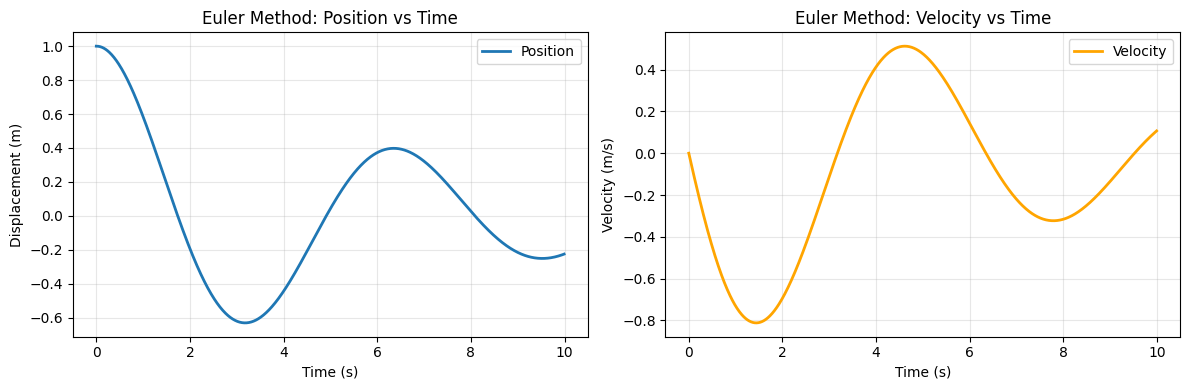

Euler solution: final position=-0.225349, final velocity=0.106683


In [2]:
def euler_method(y1_init, y2_init, t_steps, dt, m, k, c):
    """
    Solve using Euler's method
    """
    y1 = np.zeros(t_steps)
    y2 = np.zeros(t_steps)
    t = np.zeros(t_steps)
    
    # Set initial conditions
    y1[0] = y1_init
    y2[0] = y2_init
    t[0] = 0
    
    # Step forward
    for i in range(1, t_steps):
        dy1_dt, dy2_dt = spring_system(y1[i-1], y2[i-1], m, k, c)
        
        # Euler step: y_new = y_old + dy/dt * dt
        y1[i] = y1[i-1] + dy1_dt * dt
        y2[i] = y2[i-1] + dy2_dt * dt
        t[i] = t[i-1] + dt
    
    return t, y1, y2

# Run Euler method
t_euler, y1_euler, y2_euler = euler_method(y1_0, y2_0, t_steps, dt, m, k, c)

# Plot
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(t_euler, y1_euler, linewidth=2, label='Position')
plt.xlabel('Time (s)')
plt.ylabel('Displacement (m)')
plt.title('Euler Method: Position vs Time')
plt.grid(alpha=0.3)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(t_euler, y2_euler, linewidth=2, color='orange', label='Velocity')
plt.xlabel('Time (s)')
plt.ylabel('Velocity (m/s)')
plt.title('Euler Method: Velocity vs Time')
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

print(f"Euler solution: final position={y1_euler[-1]:.6f}, final velocity={y2_euler[-1]:.6f}")

## The Limitation: Euler's Method Accumulates Error
Euler is accurate only for very small step sizes. Let's test it with different `dt` values and see how error grows:

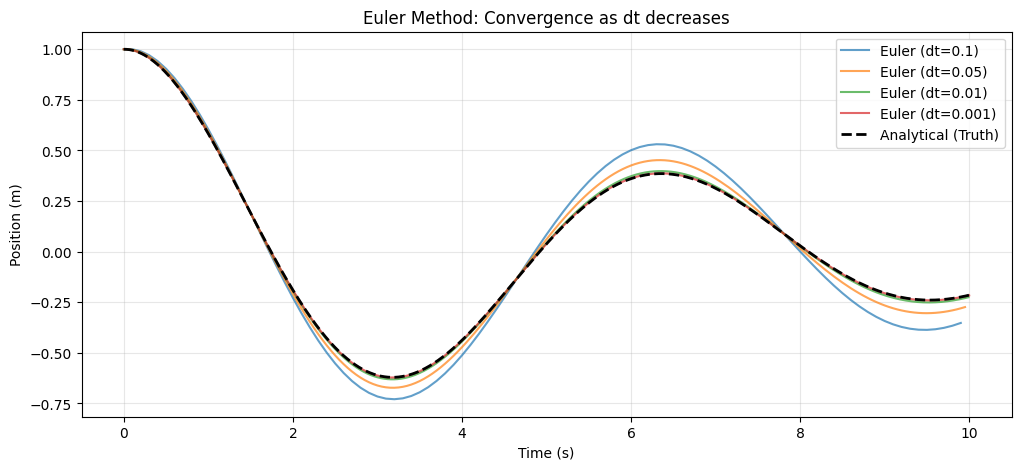

Max error for different step sizes:
  dt=0.1: max error = 0.148395
  dt=0.05: max error = 0.067061
  dt=0.01: max error = 0.012571
  dt=0.001: max error = 0.001239


In [3]:
# Analytical solution for underdamped case (simplified problem)
# For the underdamped oscillator: x(t) = e^(-gamma*t) * (A*cos(omega*t) + B*sin(omega*t))
# where gamma = c/(2m), omega = sqrt(k/m - gamma^2)

gamma = c / (2 * m)
omega_0_sq = k / m
omega_d_sq = omega_0_sq - gamma**2

if omega_d_sq > 0:
    omega_d = np.sqrt(omega_d_sq)
    # Analytical solution with y1(0)=1, y2(0)=0
    def analytical_solution(t):
        A = 1.0
        B = gamma / omega_d
        x = np.exp(-gamma * t) * (A * np.cos(omega_d * t) + B * np.sin(omega_d * t))
        return x
    
    t_analytical = np.linspace(0, t_final, 10000)
    y1_analytical = analytical_solution(t_analytical)
    
    # Test different step sizes
    dt_values = [0.1, 0.05, 0.01, 0.001]
    errors = []
    
    plt.figure(figsize=(12, 5))
    
    for idx, dt_test in enumerate(dt_values):
        steps = int(t_final / dt_test)
        t_test, y1_test, _ = euler_method(y1_0, y2_0, steps, dt_test, m, k, c)
        
        # Compare to analytical
        y1_analytical_test = analytical_solution(t_test)
        error = np.abs(y1_test - y1_analytical_test)
        max_error = np.max(error)
        errors.append(max_error)
        
        plt.plot(t_test, y1_test, alpha=0.7, label=f'Euler (dt={dt_test})', linewidth=1.5)
    
    # Overlay analytical solution
    plt.plot(t_analytical, y1_analytical, 'k--', linewidth=2, label='Analytical (Truth)')
    plt.xlabel('Time (s)')
    plt.ylabel('Position (m)')
    plt.title('Euler Method: Convergence as dt decreases')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()
    
    print("Max error for different step sizes:")
    for dt_test, err in zip(dt_values, errors):
        print(f"  dt={dt_test}: max error = {err:.6f}")
else:
    print("System is overdamped; skipping analytical comparison.")

<details>

<summary>Why does Euler accumulate error?</summary>
At each step, Euler assumes the derivative is constant over interval $dt$, but the true derivative changes. This is a truncation error of $O(dt^2)$ per step. Over N steps, errors accumulate to $O(N \cdot dt^2) = O(t_{\text{final}} \cdot dt)$—linear in step size! To halve error, you must quarter the step size.
</details>

## Runge-Kutta 4th Order (RK4): Better Accuracy
**RK4** evaluates the derivative at multiple points within each step and takes a weighted average. This reduces truncation error to $O(dt^5)$ per step, or $O(dt^4)$ globally—much better than Euler's $O(dt)$!

The formula:
$$k_1 = f(t, y)$$
$$k_2 = f(t + \frac{dt}{2}, y + \frac{dt}{2}k_1)$$
$$k_3 = f(t + \frac{dt}{2}, y + \frac{dt}{2}k_2)$$
$$k_4 = f(t + dt, y + dt \cdot k_3)$$
$$y(t+dt) \approx y(t) + \frac{dt}{6}(k_1 + 2k_2 + 2k_3 + k_4)$$

Intuition: We're computing slopes at the start, two midpoints, and the end. The weighted average (1-2-2-1) gives a better estimate.

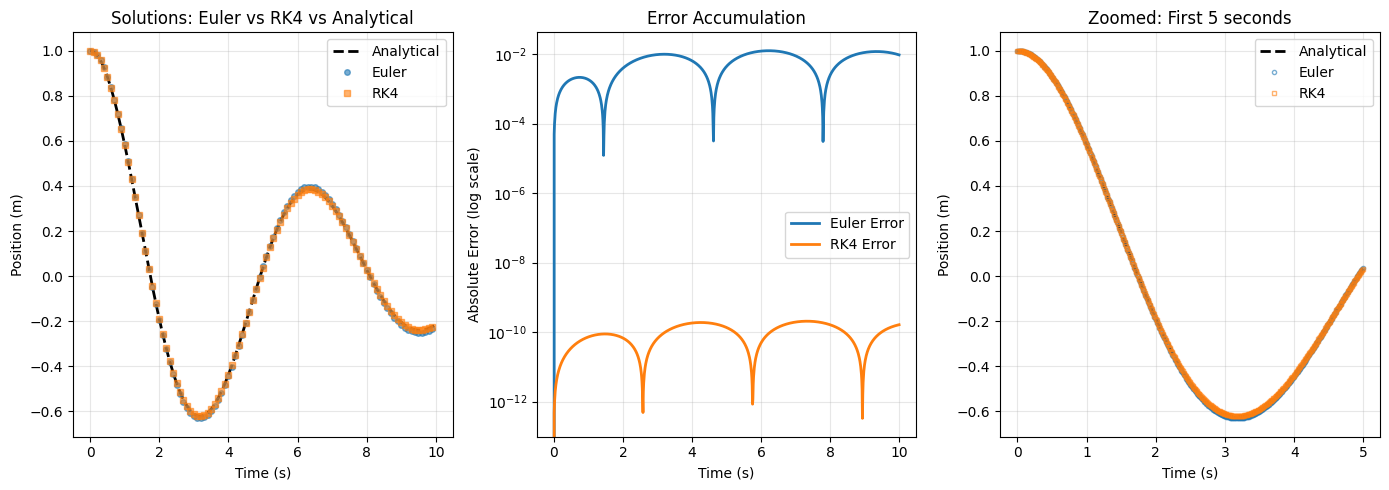

Max error - Euler: 0.01257080
Max error - RK4:   0.00000000
Error ratio (Euler/RK4): 61033012.4x


In [4]:
def rk4_method(y1_init, y2_init, t_steps, dt, m, k, c):
    """
    Solve using Runge-Kutta 4th order method
    """
    y1 = np.zeros(t_steps)
    y2 = np.zeros(t_steps)
    t = np.zeros(t_steps)
    
    # Set initial conditions
    y1[0] = y1_init
    y2[0] = y2_init
    t[0] = 0
    
    # Step forward
    for i in range(1, t_steps):
        # Current state
        y1_cur = y1[i-1]
        y2_cur = y2[i-1]
        
        # Compute four slopes
        k1_y1, k1_y2 = spring_system(y1_cur, y2_cur, m, k, c)
        
        k2_y1, k2_y2 = spring_system(y1_cur + 0.5*dt*k1_y1, 
                                      y2_cur + 0.5*dt*k1_y2, m, k, c)
        
        k3_y1, k3_y2 = spring_system(y1_cur + 0.5*dt*k2_y1, 
                                      y2_cur + 0.5*dt*k2_y2, m, k, c)
        
        k4_y1, k4_y2 = spring_system(y1_cur + dt*k3_y1, 
                                      y2_cur + dt*k3_y2, m, k, c)
        
        # Weighted average (1-2-2-1 weights)
        y1[i] = y1_cur + (dt/6.0) * (k1_y1 + 2*k2_y1 + 2*k3_y1 + k4_y1)
        y2[i] = y2_cur + (dt/6.0) * (k1_y2 + 2*k2_y2 + 2*k3_y2 + k4_y2)
        t[i] = t[i-1] + dt
    
    return t, y1, y2

# Run RK4 method
t_rk4, y1_rk4, y2_rk4 = rk4_method(y1_0, y2_0, t_steps, dt, m, k, c)

# Compare Euler vs RK4 vs Analytical
if omega_d_sq > 0:
    y1_analytical_compare = analytical_solution(t_rk4)
    
    error_euler = np.abs(y1_euler - y1_analytical_compare)
    error_rk4 = np.abs(y1_rk4 - y1_analytical_compare)
    
    plt.figure(figsize=(14, 5))
    
    # Plot 1: Solutions overlay
    plt.subplot(1, 3, 1)
    plt.plot(t_rk4, y1_analytical_compare, 'k--', linewidth=2, label='Analytical')
    plt.plot(t_rk4[::10], y1_euler[::10], 'o', alpha=0.6, label='Euler', markersize=4)
    plt.plot(t_rk4[::10], y1_rk4[::10], 's', alpha=0.6, label='RK4', markersize=4)
    plt.xlabel('Time (s)')
    plt.ylabel('Position (m)')
    plt.title('Solutions: Euler vs RK4 vs Analytical')
    plt.legend()
    plt.grid(alpha=0.3)
    
    # Plot 2: Euler error
    plt.subplot(1, 3, 2)
    plt.semilogy(t_rk4, error_euler, linewidth=2, label='Euler Error')
    plt.semilogy(t_rk4, error_rk4, linewidth=2, label='RK4 Error')
    plt.xlabel('Time (s)')
    plt.ylabel('Absolute Error (log scale)')
    plt.title('Error Accumulation')
    plt.legend()
    plt.grid(alpha=0.3, which='both')
    
    # Plot 3: Zoomed comparison
    plt.subplot(1, 3, 3)
    idx_zoom = slice(0, 500)  # First 5 seconds
    plt.plot(t_rk4[idx_zoom], y1_analytical_compare[idx_zoom], 'k--', linewidth=2, label='Analytical')
    plt.plot(t_rk4[idx_zoom], y1_euler[idx_zoom], 'o', alpha=0.6, label='Euler', markersize=3, fillstyle='none')
    plt.plot(t_rk4[idx_zoom], y1_rk4[idx_zoom], 's', alpha=0.6, label='RK4', markersize=3, fillstyle='none')
    plt.xlabel('Time (s)')
    plt.ylabel('Position (m)')
    plt.title('Zoomed: First 5 seconds')
    plt.legend()
    plt.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"Max error - Euler: {np.max(error_euler):.8f}")
    print(f"Max error - RK4:   {np.max(error_rk4):.8f}")
    print(f"Error ratio (Euler/RK4): {np.max(error_euler) / np.max(error_rk4):.1f}x")

## Testing RK4 Convergence
RK4 should show $O(dt^4)$ convergence. Let's verify:

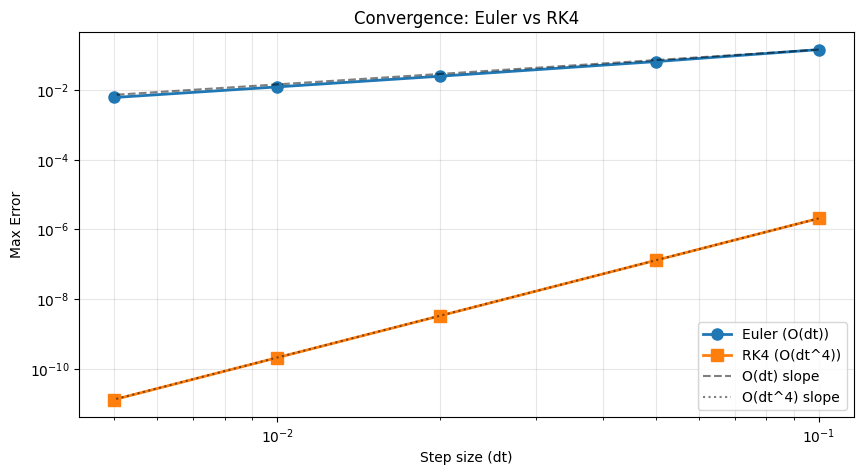

Convergence table:
      dt    Euler Error      RK4 Error      Ratio
  0.1000     0.14839529     0.00000208    71314.1x
  0.0500     0.06706100     0.00000013   518555.8x
  0.0200     0.02554797     0.00000000  7742548.9x
  0.0100     0.01257080     0.00000000 61033012.4x
  0.0050     0.00623548     0.00000000 486003197.7x


In [5]:
if omega_d_sq > 0:
    dt_values = [0.1, 0.05, 0.02, 0.01, 0.005]
    errors_rk4_conv = []
    errors_euler_conv = []
    
    for dt_test in dt_values:
        steps = int(t_final / dt_test)
        
        # Euler
        t_test_e, y1_test_e, _ = euler_method(y1_0, y2_0, steps, dt_test, m, k, c)
        y1_analytical_test = analytical_solution(t_test_e)
        error_e = np.max(np.abs(y1_test_e - y1_analytical_test))
        errors_euler_conv.append(error_e)
        
        # RK4
        t_test_rk4, y1_test_rk4, _ = rk4_method(y1_0, y2_0, steps, dt_test, m, k, c)
        y1_analytical_test_rk4 = analytical_solution(t_test_rk4)
        error_rk4_test = np.max(np.abs(y1_test_rk4 - y1_analytical_test_rk4))
        errors_rk4_conv.append(error_rk4_test)
    
    plt.figure(figsize=(10, 5))
    
    plt.loglog(dt_values, errors_euler_conv, 'o-', linewidth=2, markersize=8, label='Euler (O(dt))')
    plt.loglog(dt_values, errors_rk4_conv, 's-', linewidth=2, markersize=8, label='RK4 (O(dt^4))')
    
    # Reference slopes
    dt_ref = np.array(dt_values)
    plt.loglog(dt_ref, dt_ref * errors_euler_conv[0] / dt_values[0], 'k--', alpha=0.5, label='O(dt) slope')
    plt.loglog(dt_ref, (dt_ref**4) * errors_rk4_conv[0] / (dt_values[0]**4), 'k:', alpha=0.5, label='O(dt^4) slope')
    
    plt.xlabel('Step size (dt)')
    plt.ylabel('Max Error')
    plt.title('Convergence: Euler vs RK4')
    plt.legend()
    plt.grid(alpha=0.3, which='both')
    plt.show()
    
    print("Convergence table:")
    print(f"{'dt':>8} {'Euler Error':>14} {'RK4 Error':>14} {'Ratio':>10}")
    for dt_test, err_e, err_rk4 in zip(dt_values, errors_euler_conv, errors_rk4_conv):
        ratio = err_e / err_rk4 if err_rk4 > 0 else float('inf')
        print(f"{dt_test:8.4f} {err_e:14.8f} {err_rk4:14.8f} {ratio:10.1f}x")

<details>

<summary>Why is RK4 called "4th order"?</summary>
"Order" refers to the truncation error per step. Euler has error $O(dt^2)$ per step; RK4 has $O(dt^5)$. Over a fixed time interval, global error is one power lower: Euler is $O(dt)$, RK4 is $O(dt^4)$. This 4th power means dramatically faster convergence!
</details>

## Real-World Implications: Choosing a Method
For the spring problem, suppose we want error $< 10^{-4}$ over 10 seconds:

In [6]:
target_error = 1e-4
t_max = 10.0

# From convergence plot, estimate required dt
# For Euler: error ~ c * dt, so dt ~ error / c
# For RK4: error ~ c * dt^4, so dt ~ (error / c)^(1/4)

if omega_d_sq > 0 and len(errors_euler_conv) > 0:
    # Linear regression in log-log to estimate constants
    log_dt = np.log(dt_values)
    log_err_euler = np.log(errors_euler_conv)
    log_err_rk4 = np.log(errors_rk4_conv)
    
    # Fit slopes (should be ~1 for Euler, ~4 for RK4)
    slope_euler = np.polyfit(log_dt, log_err_euler, 1)[0]
    slope_rk4 = np.polyfit(log_dt, log_err_rk4, 1)[0]
    intercept_euler = np.polyfit(log_dt, log_err_euler, 1)[1]
    intercept_rk4 = np.polyfit(log_dt, log_err_rk4, 1)[1]
    
    # Estimate required dt
    # For Euler: error = exp(intercept) * dt^slope, solve for dt
    c_euler = np.exp(intercept_euler)
    c_rk4 = np.exp(intercept_rk4)
    
    dt_needed_euler = (target_error / c_euler) ** (1 / slope_euler)
    dt_needed_rk4 = (target_error / c_rk4) ** (1 / slope_rk4)
    
    steps_euler = int(t_max / dt_needed_euler)
    steps_rk4 = int(t_max / dt_needed_rk4)
    
    print(f"To achieve error < {target_error}:")
    print(f"\nEuler method:")
    print(f"  Required dt: {dt_needed_euler:.6f}")
    print(f"  Steps needed: {steps_euler}")
    print(f"\nRK4 method:")
    print(f"  Required dt: {dt_needed_rk4:.6f}")
    print(f"  Steps needed: {steps_rk4}")
    print(f"\nEfficiency gain: {steps_euler / steps_rk4:.0f}x fewer steps with RK4")
    print(f"Cost per step: Euler=1 evaluation, RK4=4 evaluations")
    print(f"Overall speedup: ~{(steps_euler * 1) / (steps_rk4 * 4):.1f}x faster with RK4")

To achieve error < 0.0001:

Euler method:
  Required dt: 0.000102
  Steps needed: 98353

RK4 method:
  Required dt: 0.263115
  Steps needed: 38

Efficiency gain: 2588x fewer steps with RK4
Cost per step: Euler=1 evaluation, RK4=4 evaluations
Overall speedup: ~647.1x faster with RK4


## Summary: Solving Differential Equations

| Method | Formula | Error/Step | Global Error | When to Use |
|--------|---------|-----------|--------------|-------------|
| **Euler** | $y_{n+1} = y_n + dt \cdot f(t_n, y_n)$ | $O(dt^2)$ | $O(dt)$ | Teaching, rough estimates |
| **RK4** | Weighted average of 4 slopes | $O(dt^5)$ | $O(dt^4)$ | Most practical applications |

**Key Insights:**
- Euler's simplicity is outweighed by poor accuracy; avoid in practice
- RK4 provides 4th-order accuracy with modest overhead (4 function evaluations per step)
- Higher-order methods (RK5, RK8) exist but suffer diminishing returns and complexity
- **Adaptive step size** methods vary $dt$ based on local error—often better than fixed step
- Many software libraries (scipy.integrate.odeint, numpy) use adaptive RK45; use them!

## Strengths and Weaknesses

### Strengths
- **Universal**: Works for any ODE system without needing closed-form solutions
- **Interpretable**: Step-by-step simulation mirrors physical understanding
- **Flexible**: Easy to add non-linear terms, time-dependent forces, event detection
- **Efficient**: Modern implementations with adaptive stepping are extremely fast

### Weaknesses
- **Truncation error**: Accumulates; must balance accuracy vs computational cost
- **Stability issues**: Some ODE systems are "stiff" (widely separated timescales); standard methods become unstable
- **No uniqueness guarantee**: Initial conditions may have multiple solutions (rare but possible)
- **Discretization artifacts**: Chaotic systems (nearby initial conditions → divergent paths) sensitive to numerical precision
- **Computational cost**: High-accuracy solutions can be expensive for long time intervals or high-dimensional systems